# The Curse of Dimensionality 

The Curse of Dimensionality illustrates various phenomena that arise when we work with high-dimensional data spaces that would not otherwise occur in lower-dimensional settings (such as the 3-dimensional space).

> ## Our intuitions do not hold in high-dimensional spaces 🤔

Let's illustrate this with two examples.

## Rising Complexity with Dimensionality

As dimensions increase, the volume of the feature space grows exponentially, necessitating an expansive amount of data for reliable results. Objects in this high-dimensional space appear sparse, leading to increased computational complexities and diminishing effectiveness of distance measures.

Source: (Prasan, 2023)

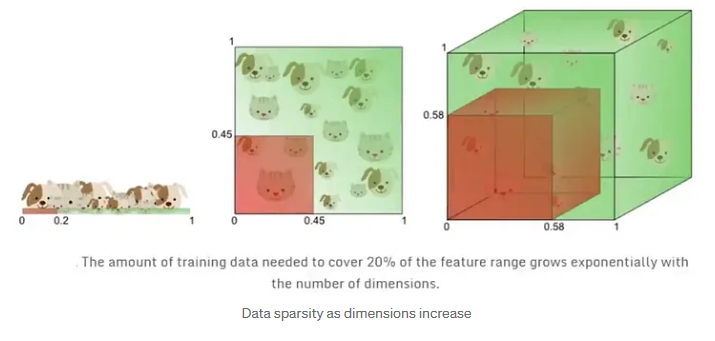

In [1]:
from IPython.display import Image
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')
import warnings
warnings.filterwarnings("ignore")


Image('figures/dimensionality.png',width=800)

In classification problems, the **curse of dimensionality** directly influences the performance of classifiers. While classifier performance improves with dimensionality initially, there exists an optimal number of features. Beyond this point, increasing dimensionality without a proportional increase in training samples results in a decline in classifier performance.

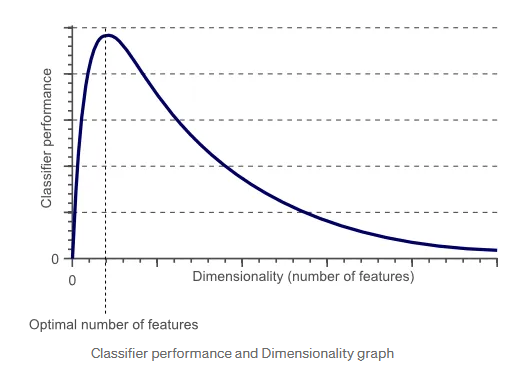

In [2]:
Image('figures/classifier_dimensions.png',width=800)

To navigate the curse of dimensionality, thoughtful consideration must be given to the number of features employed. Using too many features results in **overfitting**, emphasizing the need for dimensionality reduction. This reduction not only mitigates the curse of dimensionality but also enhances efficiency in data mining, reduces resource requirements, and aids in visualization.

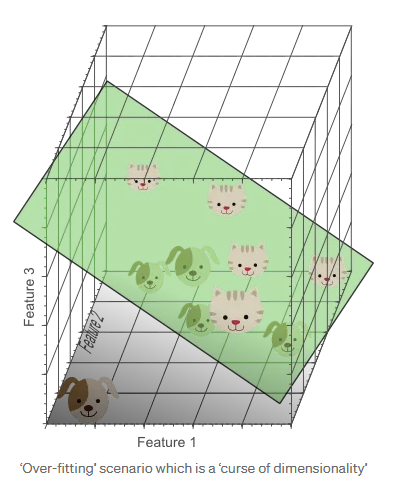

In [3]:
Image('figures/hyperplane.png',width=600)

___

## Discussions


As the dimensionality of the feature space increases, we need exponentially more data in order to explain a highly increasing volume.

We need to be careful choosing a model as that choice "injects" what we want the data to look like or follow a specific behavior. For example, in higher-dimensions, the tails of a Gaussian density function will become highly dense.

Always employ the **Occam's Razor** principle: the simplest model that works for our data is usually the most appropriate and sufficient. Model simplicity can mean different things, but we can consider a model to be complex if it has too many hyperparameter values to configure. 

When we are in a high-dimensional input space (such as images), much of that space is empty. The input data can be represented in only a few *degrees of freedom* of variability. We say that the data in *embedded* in a **manifold** of equal dimensionality as the degrees of freedom (which is drastically smaller than the input space dimensionality). We will study a few dimensionality reduction and manifold learning techniques later on in this course.

And again, intuitions or assumptions do not always hold in higher dimensions.

___

## To address the curse of dimensionality we have two approaches
**1. Feature Selection. Selects a subset of existing features**
- Embedded:Using types of regularization like Lasso
- Wrappers: Use algorithms to define a subset of features. For example: recursive feature elimination
- Filters: No need of algorithm. For example: Pearson Correlation
        
**2. Feature Extraction. Find a linear combination of the features we already have (engineering new features)**
- Principal Component Analysis
- Manifold Learning (LLE, t-SNE, etc)

# Feature Selection

Suppose that you are building the experimental design for your machine learning algorithm from a provided data set. Your first setp should include feature selection. 

In this section, we will discuss a few techniques to perform feature selection.

### Example: Wine Dataset

Let's work through with the Wine dataset, an open-source dataset that is available from the [UCI machine learning repository](https://archive.ics.uci.edu/ml/datasets/Wine); it consists of 178 wine samples with 13 features describing their different chemical properties.

In [4]:
import pandas as pd

df_wine = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data', header=None)

df_wine.columns = ['Class label', 'Alcohol',
                   'Malic acid', 'Ash',
                   'Alcalinity of ash', 'Magnesium',
                   'Total phenols', 'Flavanoids',
                   'Nonflavanoid phenols',
                   'Proanthocyanins',
                   'Color intensity', 'Hue',
                   'OD280/OD315 of diluted wines',
                   'Proline']

df_wine.head()

,Class label,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [5]:
print('Class labels ', np.unique(df_wine['Class label']))

Class labels  [1 2 3]


The samples belong to one of three different classes, 1, 2, and 3, which refer to the three different types of grapes that have been grown in different regions in Italy.

In [6]:
t = df_wine['Class label'].values

X = df_wine.drop(['Class label'], axis=1).values

X.shape, t.shape

((178, 13), (178,))

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, t_train, t_test = train_test_split(X, t, 
                                                    test_size=0.3, 
                                                    stratify=t)

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Selecting meaningful features

If we notice that a model performs much better on a training dataset than on the test dataset, this observation is a strong indicator for overfitting. Overfitting means that model fits the parameters too closely to the particular observations in the training dataset but does not generalize well to real data—we say that the model has a high variance. A reason for overfitting is that our model is too complex for the given training data and common solutions to reduce the generalization error are listed
as follows:

* Collect more training data

* Introduce a penalty for complexity via regularization

* Choose a simpler model with fewer parameters

* Reduce the dimensionality of the data

Let's look at common ways to reduce overfitting by regularization and dimensionality reduction via feature selection. 

In **feature selection**, we can have three main approaches:

1. **Filters:** for a much faster alternative, filters do not test any particular algorithm, but rank the original features according to their relationship with the problem (labels) and just select the top of them. Correlation and mutual information are the most widespread criteria. There are many easy to use tools, like the [feature selection ```scikit-learn``` package](https://scikit-learn.org/stable/modules/feature_selection.html).
    * Example: Correlation, chi-squared test, ANOVA, information gain, etc.

2. **Wrappers:** a wrapper evaluates a specific model sequentially using different potential subsets of features to get the subset that best works in the end. They are highly costly and have a high chance of overfitting, but also a high chance of success, on the other hand.
    * Example: Forward Sequential Feature Selection, Backward Feature Elimination, etc.

3. **Embedded:** this group is made up of all the Machine Learning techniques that include feature selection during their training stage. 
    * Example: LASSO, Elastic Net, Ridge, etc.

---

## 1. Embedded: Sparse solutions with L1 regularization

Recall our Linear Regression problem where we used the **L2 regularization** approach to reduce the complexity of a model by penalizing large individual weights, where we defined the L2 norm of our weight vector $\mathbf{w}$ as follows:

$$\text{L2: }\Vert\mathbf{w}\Vert_2^2 = \sum_{j=0}^M w_j^2$$

Another approach to reduce the model complexity is the related **L1 regularization**:

$$\text{L1: }\Vert\mathbf{w}\Vert_1 = \sum_{j=0}^M |w_j|$$

In contrast to L2 regularization, L1 regularization yields sparse feature vectors; most feature weights will be zero. Sparsity can be useful in practice if we have a high-dimensional dataset with many features that are irrelevant, especially cases where we have more irrelevant dimensions than samples. In this sense, L1 regularization can be understood as a technique for feature selection.

In [9]:
from sklearn.linear_model import LogisticRegression

In [10]:
# LogisticRegression?

In [11]:
lr = LogisticRegression(penalty='l1', C=0.1, solver='liblinear', multi_class='auto')

In [12]:
lr.fit(X_train, t_train)

LogisticRegression(C=0.1, multi_class='auto', penalty='l1', solver='liblinear')

In [13]:
print('Training coefficient of determination, R^2: ',lr.score(X_train, t_train))

Training coefficient of determination, R^2:  0.9758064516129032


In [14]:
print('Test coefficient of determination, R^2: ',lr.score(X_test, t_test))

Test coefficient of determination, R^2:  0.9444444444444444


Both training and test accuracies (both 98 percent) do not indicate any overfitting of our model. When we access the intercept terms via the lr.intercept_ attribute, we can see that the array returns three values:

In [15]:
lr.intercept_

array([-0.35109544, -0.11110078, -0.79971945])

Since we the fit the LogisticRegression object on a multiclass dataset, it uses the One-vs-Rest (OvR) approach by default where the first intercept belongs to the model that fits class 1 versus class 2 and 3; the second value is the intercept of the model that fits class 2 versus class 1 and 3; and the third value is the intercept of the model that fits class 3 versus class 1 and 2, respectively:

In [16]:
lr.coef_

array([[ 0.50821996,  0.        ,  0.        , -0.09465391,  0.        ,
         0.        ,  0.48939912,  0.        ,  0.        ,  0.        ,
         0.        ,  0.14265375,  1.09454296],
       [-1.10496232,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        , -0.8615085 ,
         0.        ,  0.        , -0.07772526],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        , -0.53623047,  0.        ,  0.        ,  0.43697728,
        -0.62482458, -0.47679159,  0.        ]])

The weight array that we accessed via the lr.coef_ attribute contains three rows of weight coefficients, one weight vector for each class. Each row consists of 13 weights where each weight is multiplied by the respective feature in the 13-dimensional Wine dataset to calculate the net input:

$$\mathbf{y} = \phi(w_0x_0 + w_1x_1 + \cdots + w_M x_M) = \phi\left(\sum_{j=0}^M x_j w_j\right) = \phi\left(\mathbf{w}^T\mathbf{x}\right)$$

where $\phi(\bullet)$ is the sigmoid function, $\phi(x)=\frac{1}{1+e^{-x}}$.

We notice that the weight vectors are sparse, which means that they only have a few non-zero entries. As a result of the L1 regularization, which serves as a method for feature selection, we just trained a model that is robust to the potentially irrelevant features in this dataset.

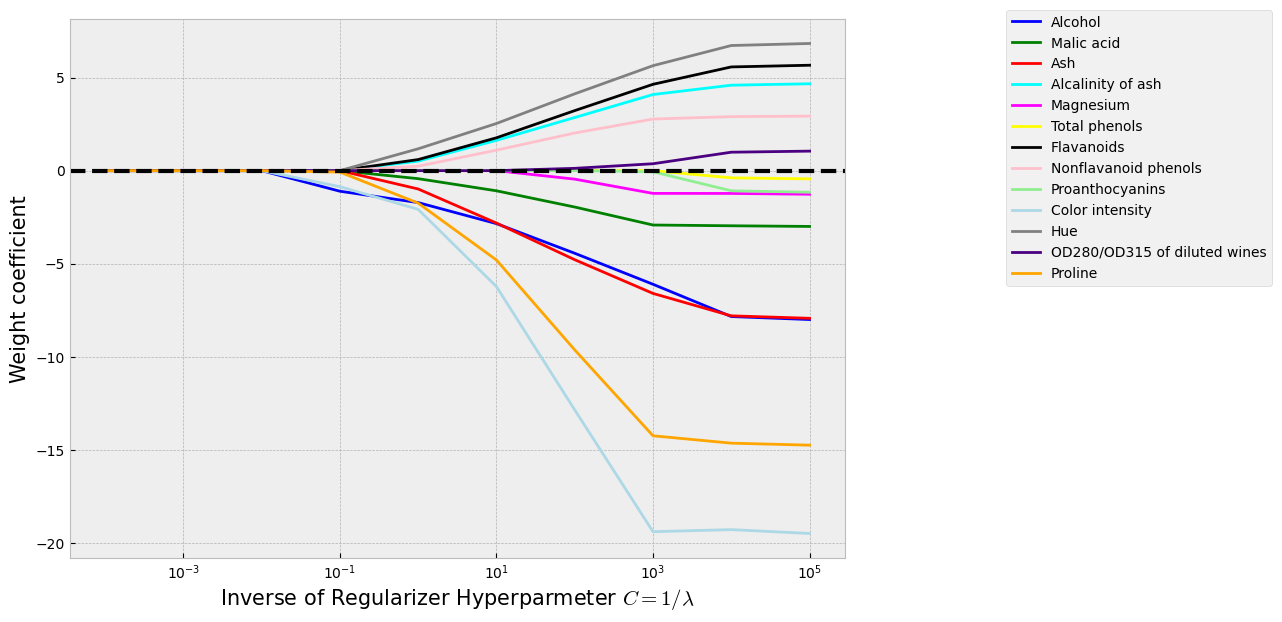

In [17]:
fig = plt.figure(figsize=(10,7))
ax = plt.subplot(111)
colors = ['blue', 'green', 'red', 'cyan', 'magenta',
          'yellow', 'black','pink', 'lightgreen',
          'lightblue','gray', 'indigo', 'orange']

weights, params = [], []

for c in np.arange(-4, 6):
    lr = LogisticRegression(penalty='l1', C=10.0**c, random_state=0, solver='liblinear', multi_class='auto')
    lr.fit(X_train, t_train)
    weights.append(lr.coef_[1])
    params.append(10.0**c)
    w = np.array(weights)
    
for column, color in zip(range(w.shape[1]), colors):
    plt.plot(params, w[:, column], label=df_wine.columns[column+1],color=color)
plt.axhline(0, color='black', linestyle='--', linewidth=3)
plt.ylabel('Weight coefficient', size=15)
plt.xlabel('Inverse of Regularizer Hyperparmeter $C=1/\lambda$',size=15)
plt.xscale('log')
plt.legend(loc='upper left',fontsize=25)
ax.legend(loc='upper center', bbox_to_anchor=(1.38, 1.03), ncol=1, fancybox=True);

The resulting plot provides us with further insights about the behavior of L1 regularization. As we can see, all features weights will be zero if we penalize the model with a strong regularization parameter ($\lambda > 0.1$).

## 2. Wrappers: Sequential feature selection algorithms

An alternative way to reduce the complexity of the model and avoid overfitting is dimensionality reduction via feature selection, which is especially useful for unregularized models. There are two main categories of dimensionality reduction techniques: feature selection and feature extraction. 

* Using feature selection, we select a subset of the original features. 
* In feature extraction, we derive information from the feature set to construct a new feature subspace.

Sequential feature selection algorithms are a family of greedy search algorithms that are used to reduce an initial $d$-dimensional feature space to a $k$-dimensional feature subspace where $k<d$. The motivation behind feature selection algorithms is to automatically select a subset of features that are most relevant to the problem to improve computational efficiency or reduce the generalization error of the model by removing irrelevant features or noise, which can be useful for algorithms that don't support regularization. 

A classic sequential feature selection algorithm is **Recursive Feature Elimination (RFE)**, which aims to reduce the dimensionality of the initial feature subspace with a minimum decay in performance of the classifier to improve upon computational efficiency. In certain cases, RFE can even improve the predictive power of the model if a model suffers from overfitting.

The idea behind the RFE algorithm is quite simple: RFE sequentially removes features from the full feature subset until the new feature subspace contains the desired number of features. In order to determine which feature is to be removed at each stage, we need to define criterion function $J$ that we want to minimize. The criterion calculated by the criterion function can simply be the difference in performance of the classifier after and before the removal of a particular feature. Then the feature to be removed at each stage can simply be defined as the feature that maximizes this criterion; or, in more intuitive terms, at each stage we eliminate the feature that causes the least performance loss after removal. Based on the preceding definition of SBS, we can outline the algorithm in 4 simple steps:

1. Initialize the algorithm with $k=d$, where $d$ is the dimensionality of the full feature space $\mathbf{X}_d$.

2. Determine the feature $x^-$ that maximizes the criterion $x^- = \arg\max J(\mathbf{X}_k - x^-)$ where $x \in \mathbf{X}_k$.

3. Remove the feature $x^-$ from the feature set.

4. Terminate if $k$ equals the number of desired features, if not, go to step 2.

In [18]:
from sklearn.feature_selection import RFE

RFE?

In [19]:
lr = LogisticRegression(penalty='l1', C=0.1, random_state=0, 
                        solver='liblinear', multi_class='auto')
lr

LogisticRegression(C=0.1, multi_class='auto', penalty='l1', random_state=0,
                   solver='liblinear')

In [20]:
rfe = RFE(estimator=lr, n_features_to_select=12, step=1)
rfe.fit(X_train, t_train)

RFE(estimator=LogisticRegression(C=0.1, multi_class='auto', penalty='l1',
                                 random_state=0, solver='liblinear'),
    n_features_to_select=12)

In [21]:
rfe.ranking_

array([1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [22]:
rfe.support_

array([ True, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True])

In [23]:
print(df_wine.columns[1:][rfe.support_])

Index(['Alcohol', 'Ash', 'Alcalinity of ash', 'Magnesium', 'Total phenols',
       'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins',
       'Color intensity', 'Hue', 'OD280/OD315 of diluted wines', 'Proline'],
      dtype='object')


In [24]:
rfe.score(X_train, t_train)

0.9758064516129032

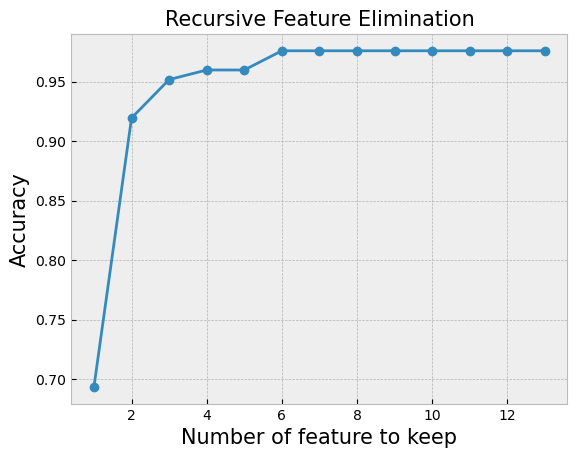

In [25]:
scores=[]
features_to_keep={}

for i in range(13):
    rfe = RFE(estimator=lr, n_features_to_select=13-i, step=1)
    rfe.fit(X_train, t_train)
    scores+=[rfe.score(X_train, t_train)] # this should be changed to the validation set!!!!
    features_to_keep[13-i]=df_wine.columns[1:][rfe.support_]

plt.plot(range(1,len(scores)+1)[::-1],scores,'-o')
plt.xlabel('Number of feature to keep',size=15)
plt.ylabel('Accuracy', size=15)
plt.title('Recursive Feature Elimination', size=15);

From this plot, we see that the classifier's performance is the same or better when using a smaller subset of features.

In [26]:
features_to_keep

{13: Index(['Alcohol', 'Malic acid', 'Ash', 'Alcalinity of ash', 'Magnesium',
        'Total phenols', 'Flavanoids', 'Nonflavanoid phenols',
        'Proanthocyanins', 'Color intensity', 'Hue',
        'OD280/OD315 of diluted wines', 'Proline'],
       dtype='object'),
 12: Index(['Alcohol', 'Ash', 'Alcalinity of ash', 'Magnesium', 'Total phenols',
        'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins',
        'Color intensity', 'Hue', 'OD280/OD315 of diluted wines', 'Proline'],
       dtype='object'),
 11: Index(['Alcohol', 'Alcalinity of ash', 'Magnesium', 'Total phenols',
        'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins',
        'Color intensity', 'Hue', 'OD280/OD315 of diluted wines', 'Proline'],
       dtype='object'),
 10: Index(['Alcohol', 'Alcalinity of ash', 'Magnesium', 'Flavanoids',
        'Nonflavanoid phenols', 'Proanthocyanins', 'Color intensity', 'Hue',
        'OD280/OD315 of diluted wines', 'Proline'],
       dtype='object'),
 9: Index(['Alcoh

In [27]:
rfe = RFE(estimator=lr, n_features_to_select=7, step=1)
rfe.fit(X_train, t_train)
rfe.score(X_train, t_train) ## this should be the validation set!!!!

0.9758064516129032

As always, we should apply cross-validation to determine the best set of features to keep:

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, ShuffleSplit, StratifiedKFold, GridSearchCV
from sklearn.metrics import confusion_matrix, roc_curve, classification_report

In [29]:
lr = LogisticRegression(penalty='l1', C=0.1,
                        solver='liblinear', multi_class='auto')

pipe = Pipeline(steps=[('RFE',RFE(lr)),
                        ('LR',lr)])
pipe

Pipeline(steps=[('RFE',
                 RFE(estimator=LogisticRegression(C=0.1, multi_class='auto',
                                                  penalty='l1',
                                                  solver='liblinear'))),
                ('LR',
                 LogisticRegression(C=0.1, multi_class='auto', penalty='l1',
                                    solver='liblinear'))])

In [30]:
# Cross-validation strategy
cv = StratifiedKFold(n_splits=2, shuffle=True)
#sample size is small
# create a single validation/training sets

# Grid Search
Cvals=np.arange(0.01,1,0.01) #L-1 penalty in Logistic Regression
n_features=range(1,14) # number of features to keep

# Parameter Grid Search
param_grid = dict(RFE__n_features_to_select=n_features)
grid_search = GridSearchCV(pipe, param_grid=param_grid, cv=cv, scoring='accuracy')

# Train the model
grid_search.fit(X_train, t_train)

# Apply the best hyperpameter values
print(grid_search.best_params_)
pipe.set_params(**grid_search.best_params_)

# Train the final model with these hyperparameter values
pipe.fit(X_train,t_train)
y_train=pipe.predict(X_train)
print('\n\nTraining Set Performance')
print('Accuracy Score:', 100*pipe.score(X_train, t_train),'%')
print('Confusion Matrix:')
print(confusion_matrix(t_train,y_train))
print('Performance Report: ')
print(classification_report(t_train,y_train))
print('\n\n')

# Evaluting final model performance in test set
y_test = pipe.predict(X_test)
print('Test Set Performance')
print('Accuracy Score:', 100*pipe.score(X_test, t_test),'%')
print('Confusion Matrix:')
print(confusion_matrix(t_test,y_test))
print('Performance Report: ')
print(classification_report(t_train,y_train))

{'RFE__n_features_to_select': 5}


Training Set Performance
Accuracy Score: 95.96774193548387 %
Confusion Matrix:
[[40  1  0]
 [ 1 48  1]
 [ 0  2 31]]
Performance Report: 
              precision    recall  f1-score   support

           1       0.98      0.98      0.98        41
           2       0.94      0.96      0.95        50
           3       0.97      0.94      0.95        33

    accuracy                           0.96       124
   macro avg       0.96      0.96      0.96       124
weighted avg       0.96      0.96      0.96       124




Test Set Performance
Accuracy Score: 96.29629629629629 %
Confusion Matrix:
[[18  0  0]
 [ 2 19  0]
 [ 0  0 15]]
Performance Report: 
              precision    recall  f1-score   support

           1       0.98      0.98      0.98        41
           2       0.94      0.96      0.95        50
           3       0.97      0.94      0.95        33

    accuracy                           0.96       124
   macro avg       0.96      0.96      

In [31]:
pipe.named_steps.RFE.support_

array([ True, False, False, False, False, False,  True, False, False,
        True,  True, False,  True])

In [32]:
df_wine.columns[1:][pipe.named_steps.RFE.support_]

Index(['Alcohol', 'Flavanoids', 'Color intensity', 'Hue', 'Proline'], dtype='object')

<div class="alert alert-info">
    <b>Feature selection algorithms in scikit-learn</b>

There are many more feature selection algorithms available via scikit-learn. Those include recursive backward elimination based on feature weights, tree-based methods to select features by importance, and univariate statistical tests. A comprehensive discussion of the different feature selection methods is beyond the scope of this book, but a good summary with illustrative examples can be found [here](http://scikit-learn.org/stable/modules/feature_selection.html).
</div>

---

## 3. Filters: Correlation Coefficient

In [33]:
df_wine.corr()

,Class label,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
Class label,1.000000,-0.328222,0.437776,-0.049643,0.517859,-0.209179,-0.719163,-0.847498,0.489109,-0.499130,0.265668,-0.617369,-0.788230,-0.633717
Alcohol,-0.328222,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720
Malic acid,0.437776,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011
Ash,-0.049643,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626
Alcalinity of ash,0.517859,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597
Magnesium,-0.209179,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351
Total phenols,-0.719163,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115
Flavanoids,-0.847498,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193
Nonflavanoid phenols,0.489109,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385
Proanthocyanins,-0.499130,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417


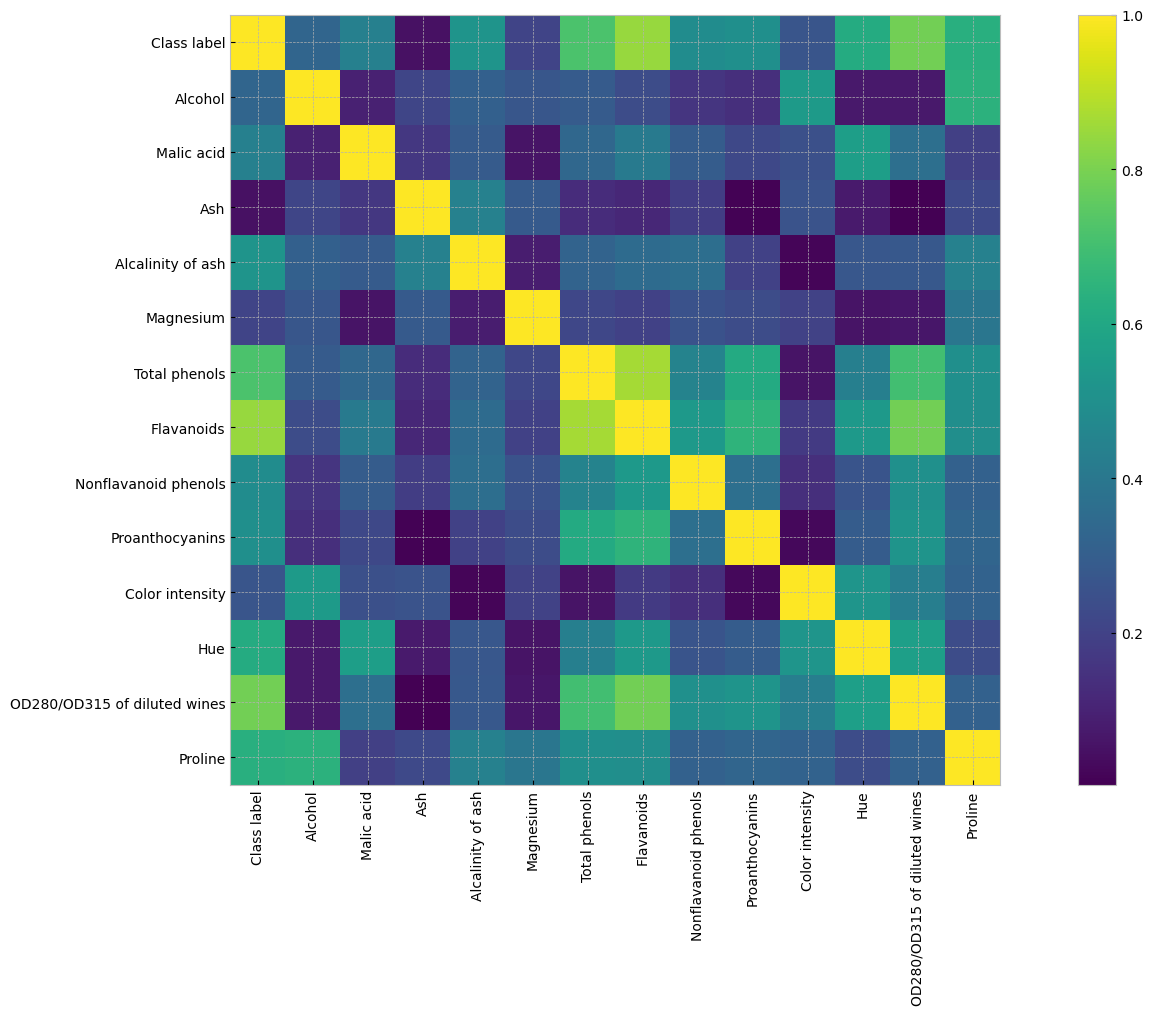

In [34]:
plt.figure(figsize=(20,10))
plt.imshow(df_wine.corr().abs(),cmap='viridis')
plt.colorbar()
plt.xticks(range(14),df_wine.columns.to_numpy(),rotation='vertical')
plt.yticks(range(14),df_wine.columns.to_numpy());

# Feature Extraction

An alternative approach to feature selection for dimensionality reduction is **feature extraction**. We will learn about a couple of fundamental techniques that will help us to summarize the information content of a dataset by transforming it onto a new feature subspace of lower dimensionality than the original one:

* **Principal Component Analysis (PCA)** for unsupervised data compression

* **Linear Discriminant Analysis (LDA)** as a supervised dimensionality reduction technique for maximizing class separability

Data compression is an important topic in machine learning, and it helps us to store and analyze the increasing amounts of data that are produced and collected in the modern age of technology.

# Principal Component Analysis (PCA)

**Principal Component Analysis (PCA)** is a dimensionality reduction technique that can be used for feature extraction. It transforms the original features into a new set of uncorrelated features called principal components (PCs). These components capture the most important variance in the data while reducing its dimensionality.

Unlike feature selection, which removes some features, PCA creates new features that are linear combinations of the original ones.

**How PCA Works for Feature Extraction**
- Standardize the Data: Center the data (subtract the mean) and optionally scale it.
- Compute Covariance Matrix: Find relationships between features.
- Eigen Decomposition: Compute eigenvalues and eigenvectors.  Use a mathematical method to find the most important patterns in the data. These patterns are called principal components.
- Select Top k Components: Choose the top k components that explain most of the variance.
- Transform the Data: Project the data onto these components, reducing the feature space.

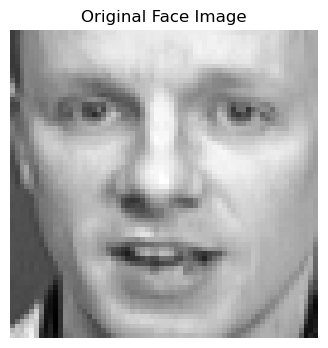

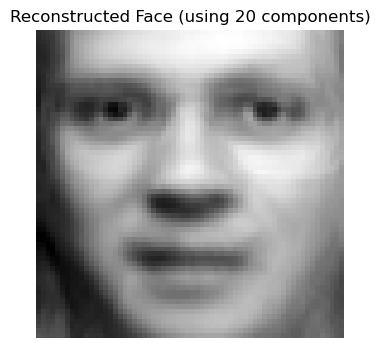

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_olivetti_faces

# Load the Olivetti Faces dataset
faces = fetch_olivetti_faces(shuffle=True, random_state=42)
X = faces.data  # Flattened 64x64 images into 4096-dimensional vectors

# Display an example face
plt.figure(figsize=(4, 4))
plt.imshow(X[0].reshape(64, 64), cmap='gray')
plt.title("Original Face Image")
plt.axis('off')
plt.show()

# Apply PCA to extract features (reduce to 50 components)
n_components = 20
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X)

# Reconstruct the face using only 50 principal components
X_reconstructed = pca.inverse_transform(X_pca)

# Display the reconstructed face
plt.figure(figsize=(4, 4))
plt.imshow(X_reconstructed[0].reshape(64, 64), cmap='gray')
plt.title(f"Reconstructed Face (using {n_components} components)")
plt.axis('off')
plt.show()
